# Problem 3: Galaxy classification
*30 points*

In this problem, we adapt the image classification notebooks from class to perform image classification on the GalaxyMNIST dataset. We will create and train a few different neural networks and quantify their performance. 

The GalaxyMNIST dataset is hosted at https://github.com/mwalmsley/galaxy-datasets. It contains 10,000 galaxy images, assigned to four categories:

```
labels = {
    0: "smooth-round", 
    1: "smooth-cigar", 
    2: "edge-on-disk", 
    3: "unbarred-spiral"
}
```

The dataset is a "debugging" subset of a much larger collection of galaxy images (with many more labels), but is sufficient for our purposes. See [arXiv:2102.08414](https://arxiv.org/abs/2102.08414), as well as the README in the git repository, for more details on how the dataset was constructed. 

### WARNING

Training the neural network will take a fair amount of time: the input images are 224 x 224 pixels, versus 28 x 28 pixels for MNIST, so training will take roughly 100x as long. On my M4 Pro CPU, the first step takes about 15 minutes to train. Therefore, you will have to start early and plan carefully. Some recommendations:

- Use `tqdm` to create a progress bar with time estimate during the training. If the time estimate is too large, you can stop the kernel and revise the parameters to achieve a reasonable training time.
- Each time you obtain a successful training, **save the results**! The Jax MNIST notebook shows how to export the trained weights at the end. See the notebook `restore.ipynb` for how to load the saved parameters.
- Given the computational limitations of running this on a laptop, you will not be graded on absolute accuracy, but rather on following the right training and evaluation methods. 

In [14]:
import os
import numpy as np
import requests
import gzip
import shutil
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import hist
import tensorflow as tf
import tensorflow_datasets as tfds
from tqdm import tqdm



### Dataset loader

For this problem, a `tensorflow_dataset` wrapper has been created to load the dataset in exactly the same way as the JAX MNIST tutorial. The wrapper is in a python package at https://github.com/ubsuny/galaxy_datasets. If you are using the Docker container, this python package has already been installed (run `docker pull ubsuny/compphys:latest` to pull the latest version). Otherwise, you can install it with pip:

`pip install git+https://github.com/ubsuny/galaxy_datasets@v0.1`

The first time you run this notebook, the dataset will be downloaded to `data_dir`. If you are using the Docker container, make sure that `data_dir` is somewhere persistent, otherwise it will get deleted every time you stop the container.

In [15]:
tfds.disable_progress_bar() # Verbose extraction step breaks the progress bar
tf.random.set_seed(0)  # Set the random seed for reproducibility.

train_steps = 2500
eval_every = 50
batch_size = 16

train_ds: tf.data.Dataset
ds_info: tfds.core.DatasetInfo
train_ds, ds_info = tfds.load("GalaxyMNIST", split="train", with_info=True, data_dir="./data") #GalaxyMNIST(split="train")

# Image preprocessing
train_ds = train_ds.map(
  lambda sample: {
    'image': tf.cast(sample['image'], tf.float32) / 255,
    #'image': tf.reduce_mean(tf.cast(sample['image'], tf.float32), axis=-1, keepdims=True) / 255,
    'label': sample['label'],
  }
)  # normalize train set

test_ds = tfds.load("GalaxyMNIST", split="test", data_dir="./data") #GalaxyMNIST(split="test")

test_ds = test_ds.map(
  lambda sample: {
    'image': tf.cast(sample['image'], tf.float32) / 255,
    #'image': tf.reduce_mean(tf.cast(sample['image'], tf.float32), axis=-1, keepdims=True) / 255,
    'label': sample['label'],
  }
)  # Normalize the test set.

# Create a shuffled dataset by allocating a buffer size of 1024 to randomly draw elements from.
train_ds = train_ds.repeat().shuffle(1024)
# Group into batches of `batch_size` and skip incomplete batches, prefetch the next sample to improve latency.
train_ds = train_ds.batch(batch_size, drop_remainder=True).take(train_steps).prefetch(8)
# Group into batches of `batch_size` and skip incomplete batches, prefetch the next sample to improve latency.
test_ds = test_ds.batch(batch_size, drop_remainder=True).prefetch(8)

tfds.enable_progress_bar()
print("Done")


Done


Cat 0 = smooth-round
Cat 1 = smooth-cigar
Cat 2 = edge-on-disk
Cat 3 = unbarred-spiral


2026-03-31 21:31:05.417461: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


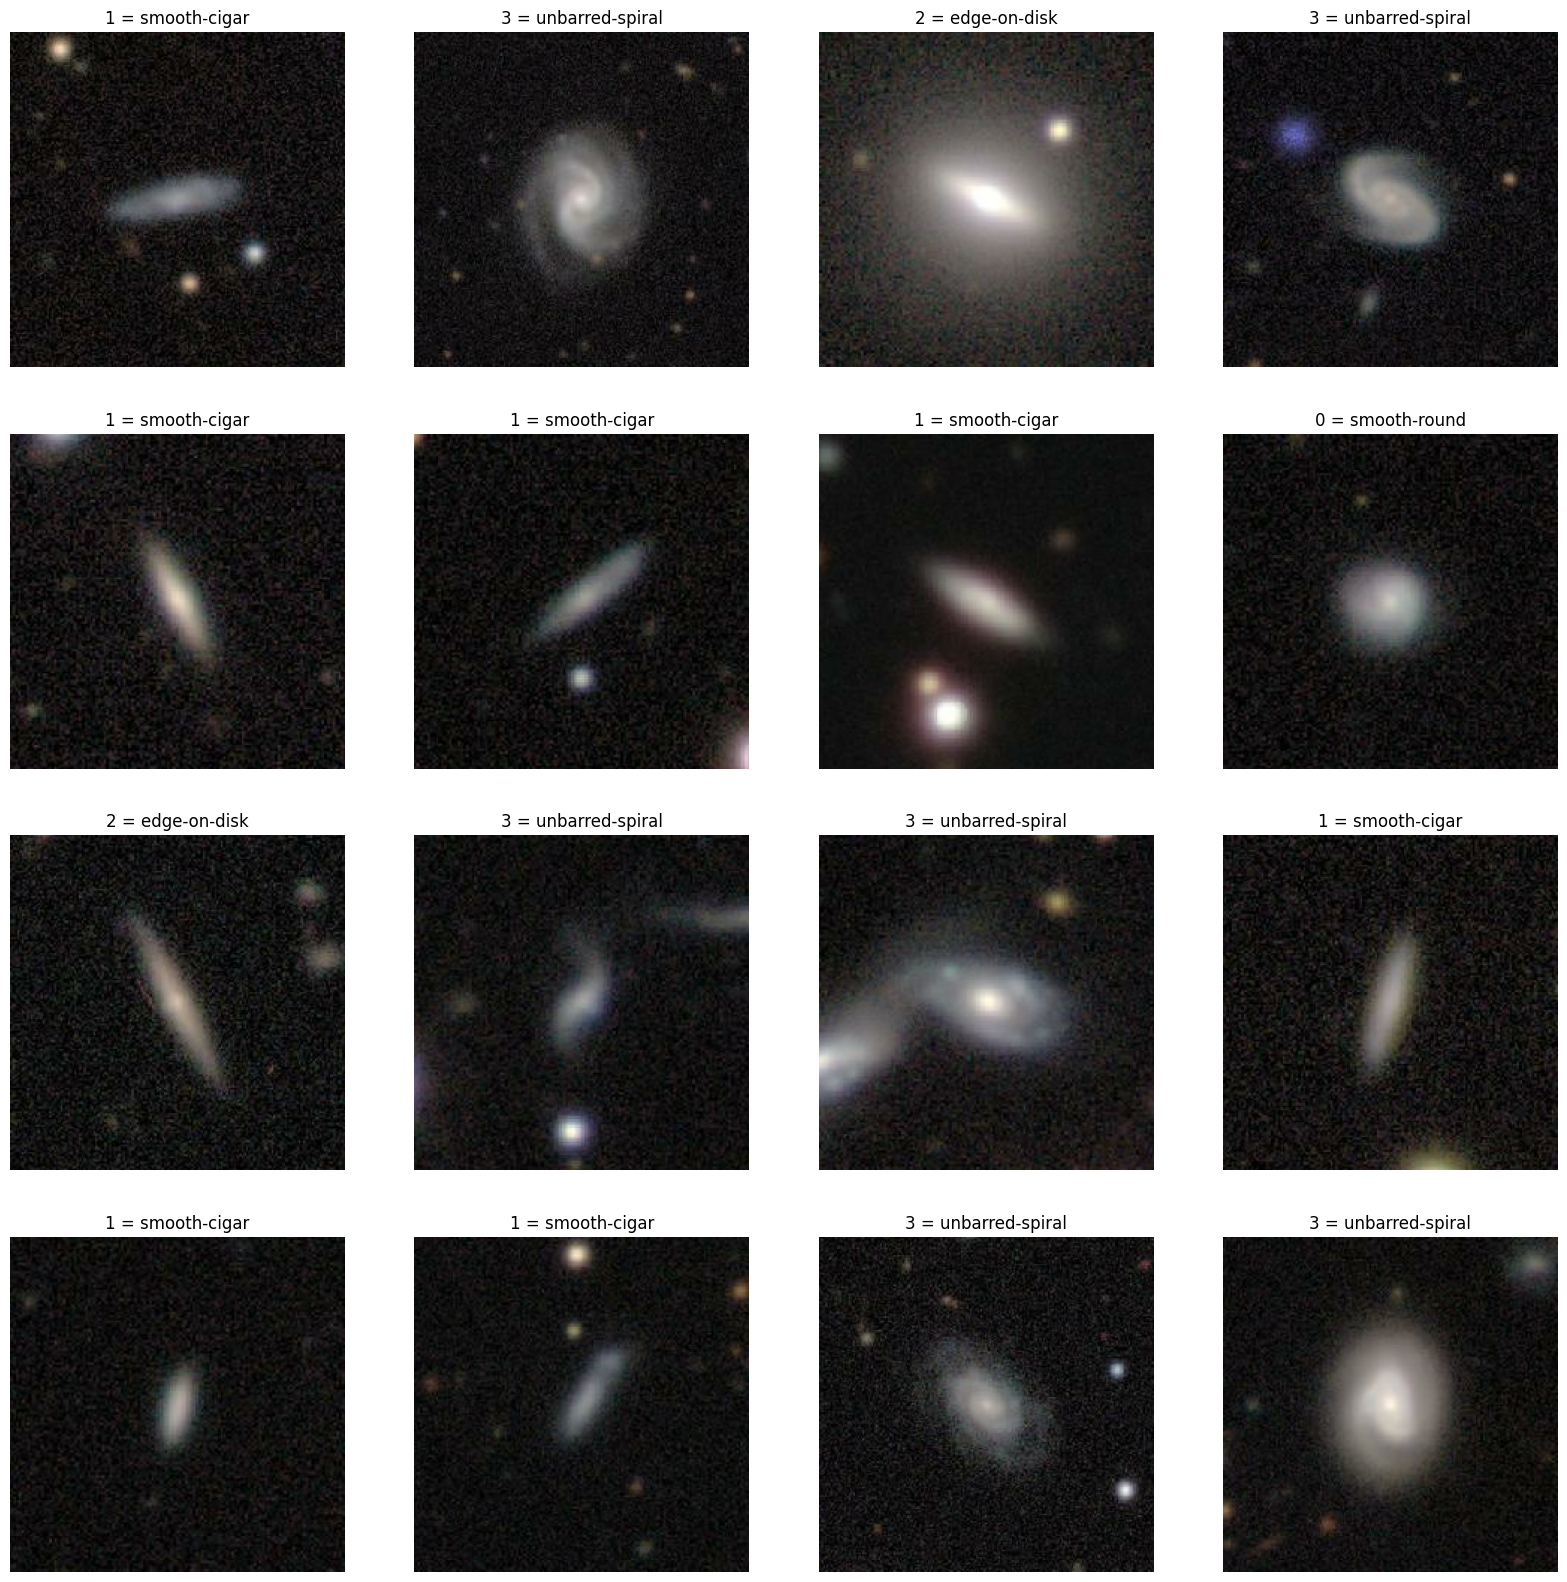

In [38]:
# Label info
ds_info
cat_map = ds_info.features["label"]
for i in range(4):
    print(f"Cat {i} = {cat_map.int2str(i)}")

# Inspect a few images
fig, axs = plt.subplots(4, 4, figsize=(20, 20))
test_batch = test_ds.take(1).as_numpy_iterator().next()
#for i, example in enumerate(test_ds.take(1)):
for i, ax in enumerate(axs.flatten()):
    axs.flatten()[i].imshow(test_batch["image"][i, :, :])
    axs.flatten()[i].set_title(f"{test_batch['label'][i]} = {cat_map.int2str(test_batch['label'][i])}")
    axs.flatten()[i].axis("off")


## Problem 3a
*20 points*

Adapt the MNIST tutorial to classify the GalaxyMNIST images. The MNIST tutorial has been copied to this folder. You will need to modify a few things in the training:
- Change the sizes of the layers to handle different size of the GalaxyMNIST pictures (224 * 224 * 3 vs. 28 * 28 * 1).
    - Note, the 3 reflect the fact that the images are RGB (3 colors) rather than greyscale.
- Downscale more aggressively in the pooling layers, to speed up the training (if you had proper hardware like a GPU cluster, you probably wouldn't want to do this!). For the 2 CNN layers, I suggest trying downscaling by a factor of 4 after the first layer and 8 after the second layer. Remember to adjust both `window_shape` and `strides`. 

Once you have trained the network, evaluate it on the test dataset. In your writeup, include the following:
- Plot of cost function versus training iteration. How do the train and test curves differ, and what do they say about overtraining?
- The classification accuracy of the network.
- A plot of the confusion matrix, i.e., the 4x4 matrix of possible outcomes (4 true categories times 4 classifier categories). Discuss the performance: where does the network perform better or worse?
- A few example plots of misclassified galaxies.


In [13]:
# Modified MNIST code goes here


## Problem 3b: ROC curve
*10 points* 

Now consider your network as a binary classifier for the `unbarred-spiral` category (category 3). In other words, instead of selecting the single category with the highest score, we just care about whether a galaxy in `unbarred-spiral` or not. Specifically, let $p$ be the probability returned by the network for the `unbarred-spiral`category. For a given threshold $x\in[0, 1]$, we classify the image as `unbarred-spiral` if $p>x$.

We characterize the performance with two numbers:
1. Signal efficiency: the rate of classifying true unbarred-spiral images as `unbarred_spiral` (true positives), and
2. Fake rate: the rate of classifying non-`unbarred_spiral` images as `unbarred_spiral` (false positives).

The ROC curve is a visualization of the true positive vs. fake positive rate, scanning $x$ values over the whole range $[0, 1]$. See e.g. https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc for more information. 

Create a ROC plot, i.e., plot the signal efficiency (y-axis) vs. fake rate (x-axis) for $x\in[0, 1]$. Compute the "area under the curve" (AUC) metric by integrating the curve, and draw the AUC on the plot (remember, the AUC is 1 for a perfect classifier, and 0.5 for random guesses). Upload the ROC plot to your writeup, and discuss the results. 

(Comment: the AUC is a popular metric for machine learning competitions. In physics, we are typically more concerned with finding the point on the ROC curve that gives the best signal-vs-background discrimination, e.g., $s/\sqrt{b}$.)


## Problem 3c: improving performance
*10 points*

**PHY506 students only.**

Run a few ($\approx 3$) experiments modifying the network to try to improve the performance. You might want to read through https://www.kaggle.com/code/cdeotte/how-to-choose-cnn-architecture-mnist for inspiration. For example, you could try:

- Instead of aggressively downsampling (e.g. by a factor of 8), add a 3rd convolutional layer with pooling.
- Vary the size of the kernel.
- Try a simple multilayer perceptron instead of a CNN.
- Modify the batch size or training rate (but beware blowing up the training time!).

To avoid problems with versioning, variable name conflicts, accidentally reusing old variables, etc..., you might want to create a new notebook for each experiment. 

In your writeup, for each experiment, describe what you varied, provide the total classification accuracy (don't worry about the other metrics, unless you are curious), and discuss your findings. Again, given the limitations of runnign this on your laptop, you will not be graded on the absolute performance of your NN!
